# Repaired reproducibility version

Derived from the original supplementary notebook. Original plotting/analysis cells are retained; only documented path, environment, missing-helper and unambiguous stale-variable fixes were applied. See `../REPAIR_LOG.md` for every change and items requiring manual confirmation.

In [1]:
source('../shared/r_funcs_repro.r')

# figure S4

- kernel: r_env, R 4.1.3
- date: 2024-01-19
- desc: supplementary figure 4

## load

In [2]:
library(tidyverse)
library(logging)
library(ggpubr)
library(ggsci)
library(patchwork)

source('../shared/r_funcs_repro.r')

theme_set(theme_pubr())
logging::basicConfig()
options(warn = -1)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.1.0
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
# basical informatino
outdir <- '../../output/figs4'
create_dir(outdir)
f_pat_gp <- '../../data/tables/patient_info_v2.tsv'
f_cell_state <- '../../data/figures/fig3/fig3-net_tcr_sharing-node_info.tsv'

In [4]:
gp <- 'response'

gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_lvls$response <- c('R', 'NR')
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

## virus detection status in major cell type

- desc: virus-detected means > 0 reads mapped to virus

In [5]:
f_obs <- '../../data/stage4/a24_microbe/domain_lvl/whole_obs_with_domain_logrpm.rds'
cutoff <- 0
ctype_map <- list(
    'B & Plasma' = c('B', 'Plasma'),
    'T cells' = c('T')
)
ctype_order <- c('B & Plasma', 'Myeloid', 'T cells', 'Endothelial', 'Epithelial', 'Fibroblast')

In [6]:
meta <- readRDS(f_obs)
meta$celltype <- meta$cell_type_correct
for (nm in names(ctype_map)) {
    meta$celltype[meta$cell_type_correct %in% ctype_map[[nm]]] <- nm
}

table(meta$celltype, meta$Viruses != 0, useNA = 'ifany')

             
               FALSE   TRUE   <NA>
  B & Plasma   83532  19649     31
  Endothelial  34688   9349     18
  Epithelial   51237  23750     53
  Fibroblast   87797  23322     45
  Myeloid      89475  24917    244
  T cells     269138  32360    527

### overview: s4a

In [7]:
# rpm to binary, show proportion in cell types
df <- meta %>%
    mutate(bi_type = case_when(
        is.na(Viruses) ~ NA_character_,
        Viruses > cutoff ~ 'Virus-detected',
        Viruses <= cutoff ~ 'Non-detected',
        TRUE ~ 'others'
    )) %>%
    count(celltype, bi_type, name = 'n_cell')
df %>% write_tsv(str_glue('{outdir}/figs4a-virus_detection_in_macrotype-bi-cell_cnt.tsv'))

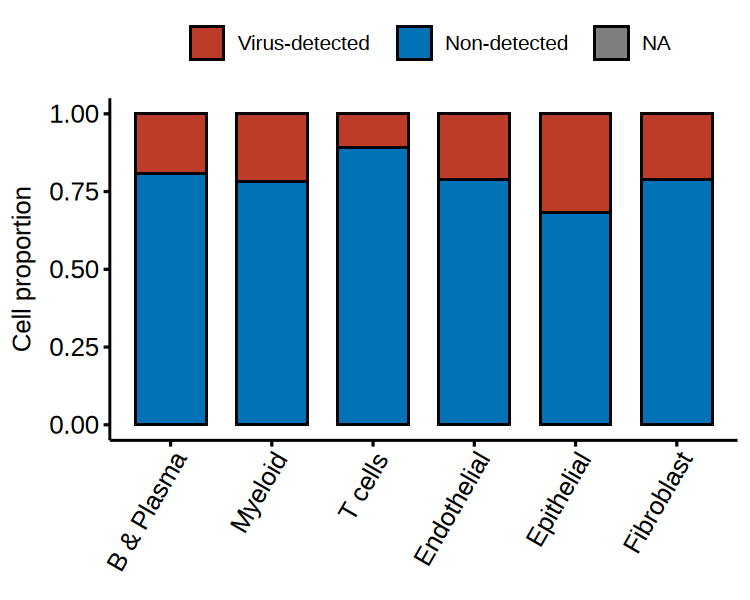

In [8]:
# plot
p <- read_tsv(str_glue('{outdir}/figs4a-virus_detection_in_macrotype-bi-cell_cnt.tsv'), show_col_types = F) %>%
    mutate(bi_type = factor(bi_type, c('Virus-detected', 'Non-detected')),
           celltype = factor(celltype, ctype_order)) %>%
    ggbarplot(x = 'celltype', y = 'n_cell', fill = 'bi_type', position = position_fill()) +
    scale_fill_nejm(na.value = 'gray50') +
    labs(y = 'Cell proportion', fill = '') +
    theme(axis.title.x = element_blank(), axis.text.x = element_text(angle = 60, hjust = 0.98))
ggsave(filename = str_glue('{outdir}/figs4a-bar-virus_dist_in_macrotype.pdf'), width = 5, height = 4, plot = p)
jp_opt(wd = 5, hg = 4)
print(p)


### sample level: s4b

- desc: min 50 cells each sample each major cell type

In [13]:
min_cell <- 50

# rpm to binary, show proportion in cell types at sample level
df <- meta %>%
    mutate(bi_type = case_when(
        is.na(Viruses) ~ NA_character_,
        Viruses > cutoff ~ 'Virus-detected',
        Viruses <= cutoff ~ 'Non-detected',
        TRUE ~ 'others'
    )) %>%
    count(celltype, sample, bi_type, name = 'n_cell') %>%
    add_count(celltype, sample, wt = n_cell, name = 'n_cell_per_sample_ctype') %>%
    filter(n_cell_per_sample_ctype >= min_cell) %>%
    mutate(pct = 100 * n_cell / n_cell_per_sample_ctype) %>%
    pivot_wider(id_cols = c('sample', 'celltype',), 
                names_from = 'bi_type', values_from = 'pct', values_fill = 0) %>%
    separate(col = 'sample', into = c('patient', 'sample_type'), sep = '-', remove = F) %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post')) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
df %>% write_tsv(str_glue('{outdir}/figs4b-virus_detection_in_macrotype-bi-sample_lvl-pct.tsv'))

2026-07-18 17:35:49.527908 INFO::these clinial info will be added: response


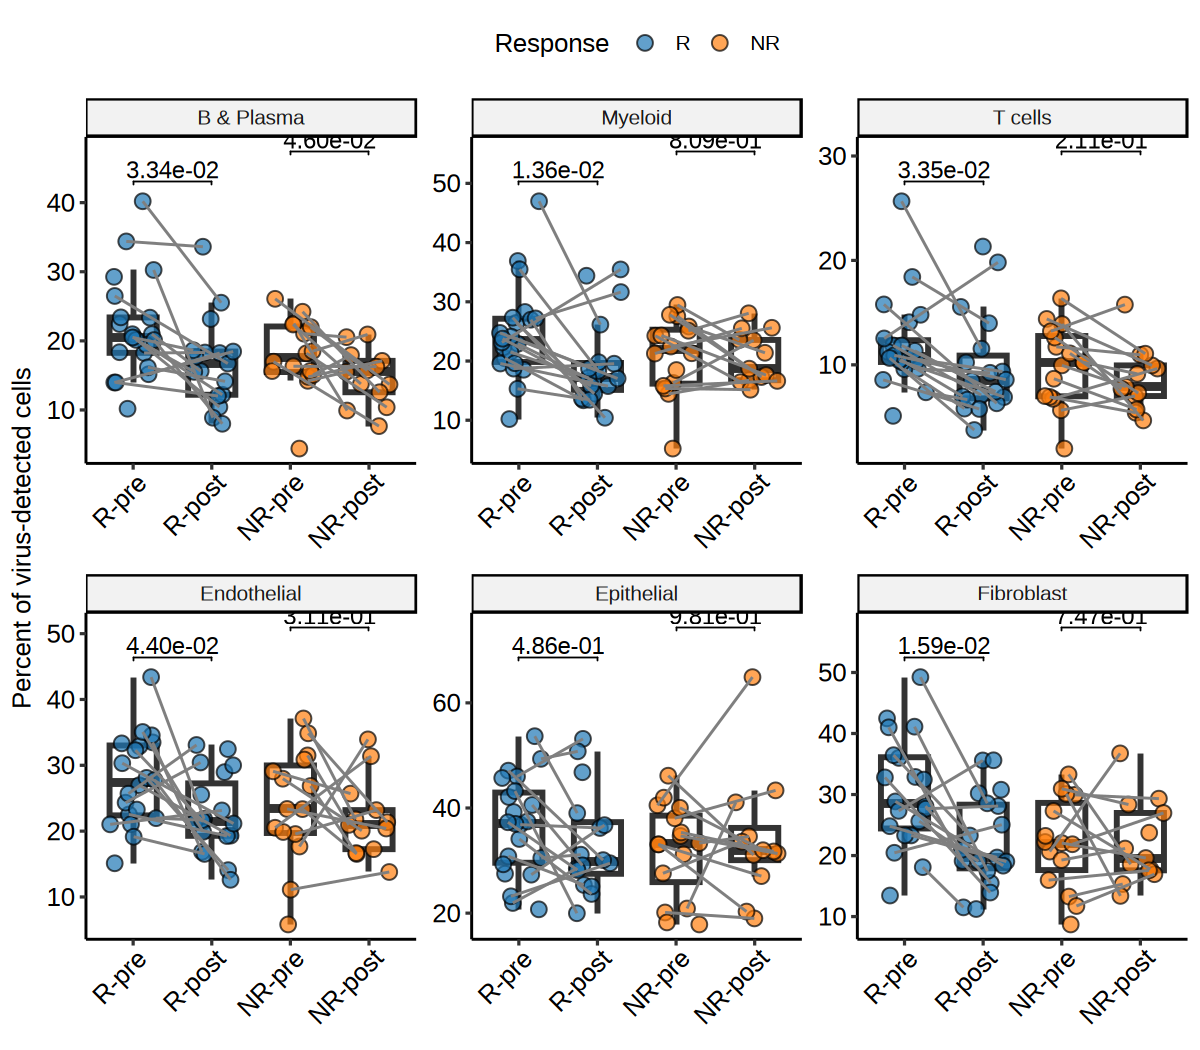

In [14]:
p <- read_tsv(str_glue('{outdir}/figs4b-virus_detection_in_macrotype-bi-sample_lvl-pct.tsv'), show_col_types = F) %>% 
    filter(!is.na(.data[[gp]])) %>%
    mutate(celltype = factor(celltype, ctype_order)) %>% 
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'Virus-detected', pt_fill = gp, pair_by = 'patient', 
                      xorder = comb_order, fill_order = gp_lvls[[gp]], facet_by = 'celltype', ncol = 3) +
    labs(y = 'Percent of virus-detected cells', fill = 'Response') +
    theme(axis.title.x = element_blank())
p <- add_bh_wilcox(
    plot = p,
    comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    x = 'plot_x', y = 'Virus-detected', facet_by = 'celltype',
    stats_file = str_glue('{outdir}/figs4b-box_virus_detected_cells-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs4b-box_cell_pct-virus_detected_cells.pdf'), width = 8, height = 7, plot = p)
jp_opt(wd = 8, hg = 7)
print(p)


In [11]:
# T cell state mapping
df <- read_tsv(f_cell_state, show_col_types = F)

cell_state_order <- c('cytotoxic', 'exhausted', 'dying', 'others', 'NK')
cell_state_map <- split(df$node, df$node_type)
cell_state_map$NK <- c('NK', 'NK_CX3CR1')
cell_state_map <- cell_state_map[cell_state_order]

cell_state_color <- c('exhausted' = '#023fa5', 'cytotoxic' = 'red', 
                      'dying' = '#bb7784', 'others' = '#ff9639',
                      'NK' = 'gray50')

In [12]:
cell_state_map

$cytotoxic
[1] "CD8_ANXA1"  "CD8_CCL5"   "CD8_CX3CR1" "CD8_FOS"    "CD8_GZMK"  
[6] "CD8_KLRB1" 

$exhausted
[1] "CD4_CXCL13"   "CD8_CXCL13"   "CD8_TYMS"     "T_MKI67"      "Treg_TNFRSF4"

$dying
[1] "T_Mito"

$others
[1] "CD4_KLRB1" "CD8_CD74"  "CD8_IFIT1" "T_IL7R"    "T_Ribo"    "Treg_LTB" 

$NK
[1] "NK"        "NK_CX3CR1"